# 02 · Measure the motion models

**NFL Player Trajectory Lab** · Chronological validation · Holdout reserved

Compare five physical references with a role-conditioned ridge model. The ridge model
learns six shared x/y vector weights for each role, using only training-game sufficient
statistics. Fixed regularization is declared in the protocol before evaluation.

This is a local experiment, not a Kaggle leaderboard score or a medal claim.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
LOCAL = ROOT / "artifacts" / "benchmark"
PUBLISHED = ROOT / "docs" / "results"
RESULTS = LOCAL if (LOCAL / "summary.json").exists() else PUBLISHED
READY = (RESULTS / "summary.json").exists()
if READY:
    summary = json.loads((RESULTS / "summary.json").read_text())
    eda = json.loads((RESULTS / "eda.json").read_text())
    protocol = json.loads((RESULTS / "protocol.json").read_text())
    display(
        Markdown(
            "**Report source:** "
            + (
                "local benchmark artifacts"
                if RESULTS == LOCAL
                else "published reproducible experiment snapshot"
            )
        )
    )
else:
    display(
        Markdown(
            "Run `nfl benchmark` after the data audit to create the real-data results. "
            "No synthetic result is substituted here."
        )
    )

**Report source:** local benchmark artifacts

## The official metric

$$\mathrm{RMSE}=\sqrt{rac{\sum_{i=1}^{N}[(\hat{x}_i-x_i)^2+(\hat{y}_i-y_i)^2]}{2N}}.$$

Coordinates are measured in yards. Every coordinate/frame receives equal weight.
ADE measures Euclidean displacement, FDE measures each trajectory's final displacement,
and p95 reports the error tail. They complement RMSE; they are different quantities.

In [2]:
if READY:
    scores = pd.DataFrame(summary["models"])
    display(
        scores[
            [
                "model",
                "coordinate_rmse_yards",
                "rmse_ci95_low",
                "rmse_ci95_high",
                "ade_frame_weighted_yards",
                "fde_trajectory_weighted_yards",
                "p95_displacement_yards",
            ]
        ].round(4)
    )
    best = scores.iloc[0]
    display(
        Markdown(
            f"**Selected for further research:** `{best['model']}`. "
            f"RMSE is **{summary['improvement_vs_velocity_percent']:.1f}% lower** "
            "than constant velocity on these validation games."
        )
    )

,model,coordinate_rmse_yards,rmse_ci95_low,rmse_ci95_high,ade_frame_weighted_yards,fde_trajectory_weighted_yards,p95_displacement_yards
0,role_ridge,0.9896,0.9218,1.0519,0.8847,1.5057,3.0028
1,constant_velocity,1.7225,1.6285,1.8062,1.5142,2.8696,5.4431
2,constant_acceleration,1.9965,1.7936,2.1926,1.3073,2.6664,5.6911
3,smoothed_velocity,2.0051,1.9043,2.0992,1.8581,3.3798,6.2825
4,ball_arrival,4.0842,3.8749,4.2894,3.8607,5.6192,12.5779
5,last_position,4.4806,4.2242,4.7262,4.4882,6.5526,14.0034


**Selected for further research:** `role_ridge`. RMSE is **42.6% lower** than constant velocity on these validation games.

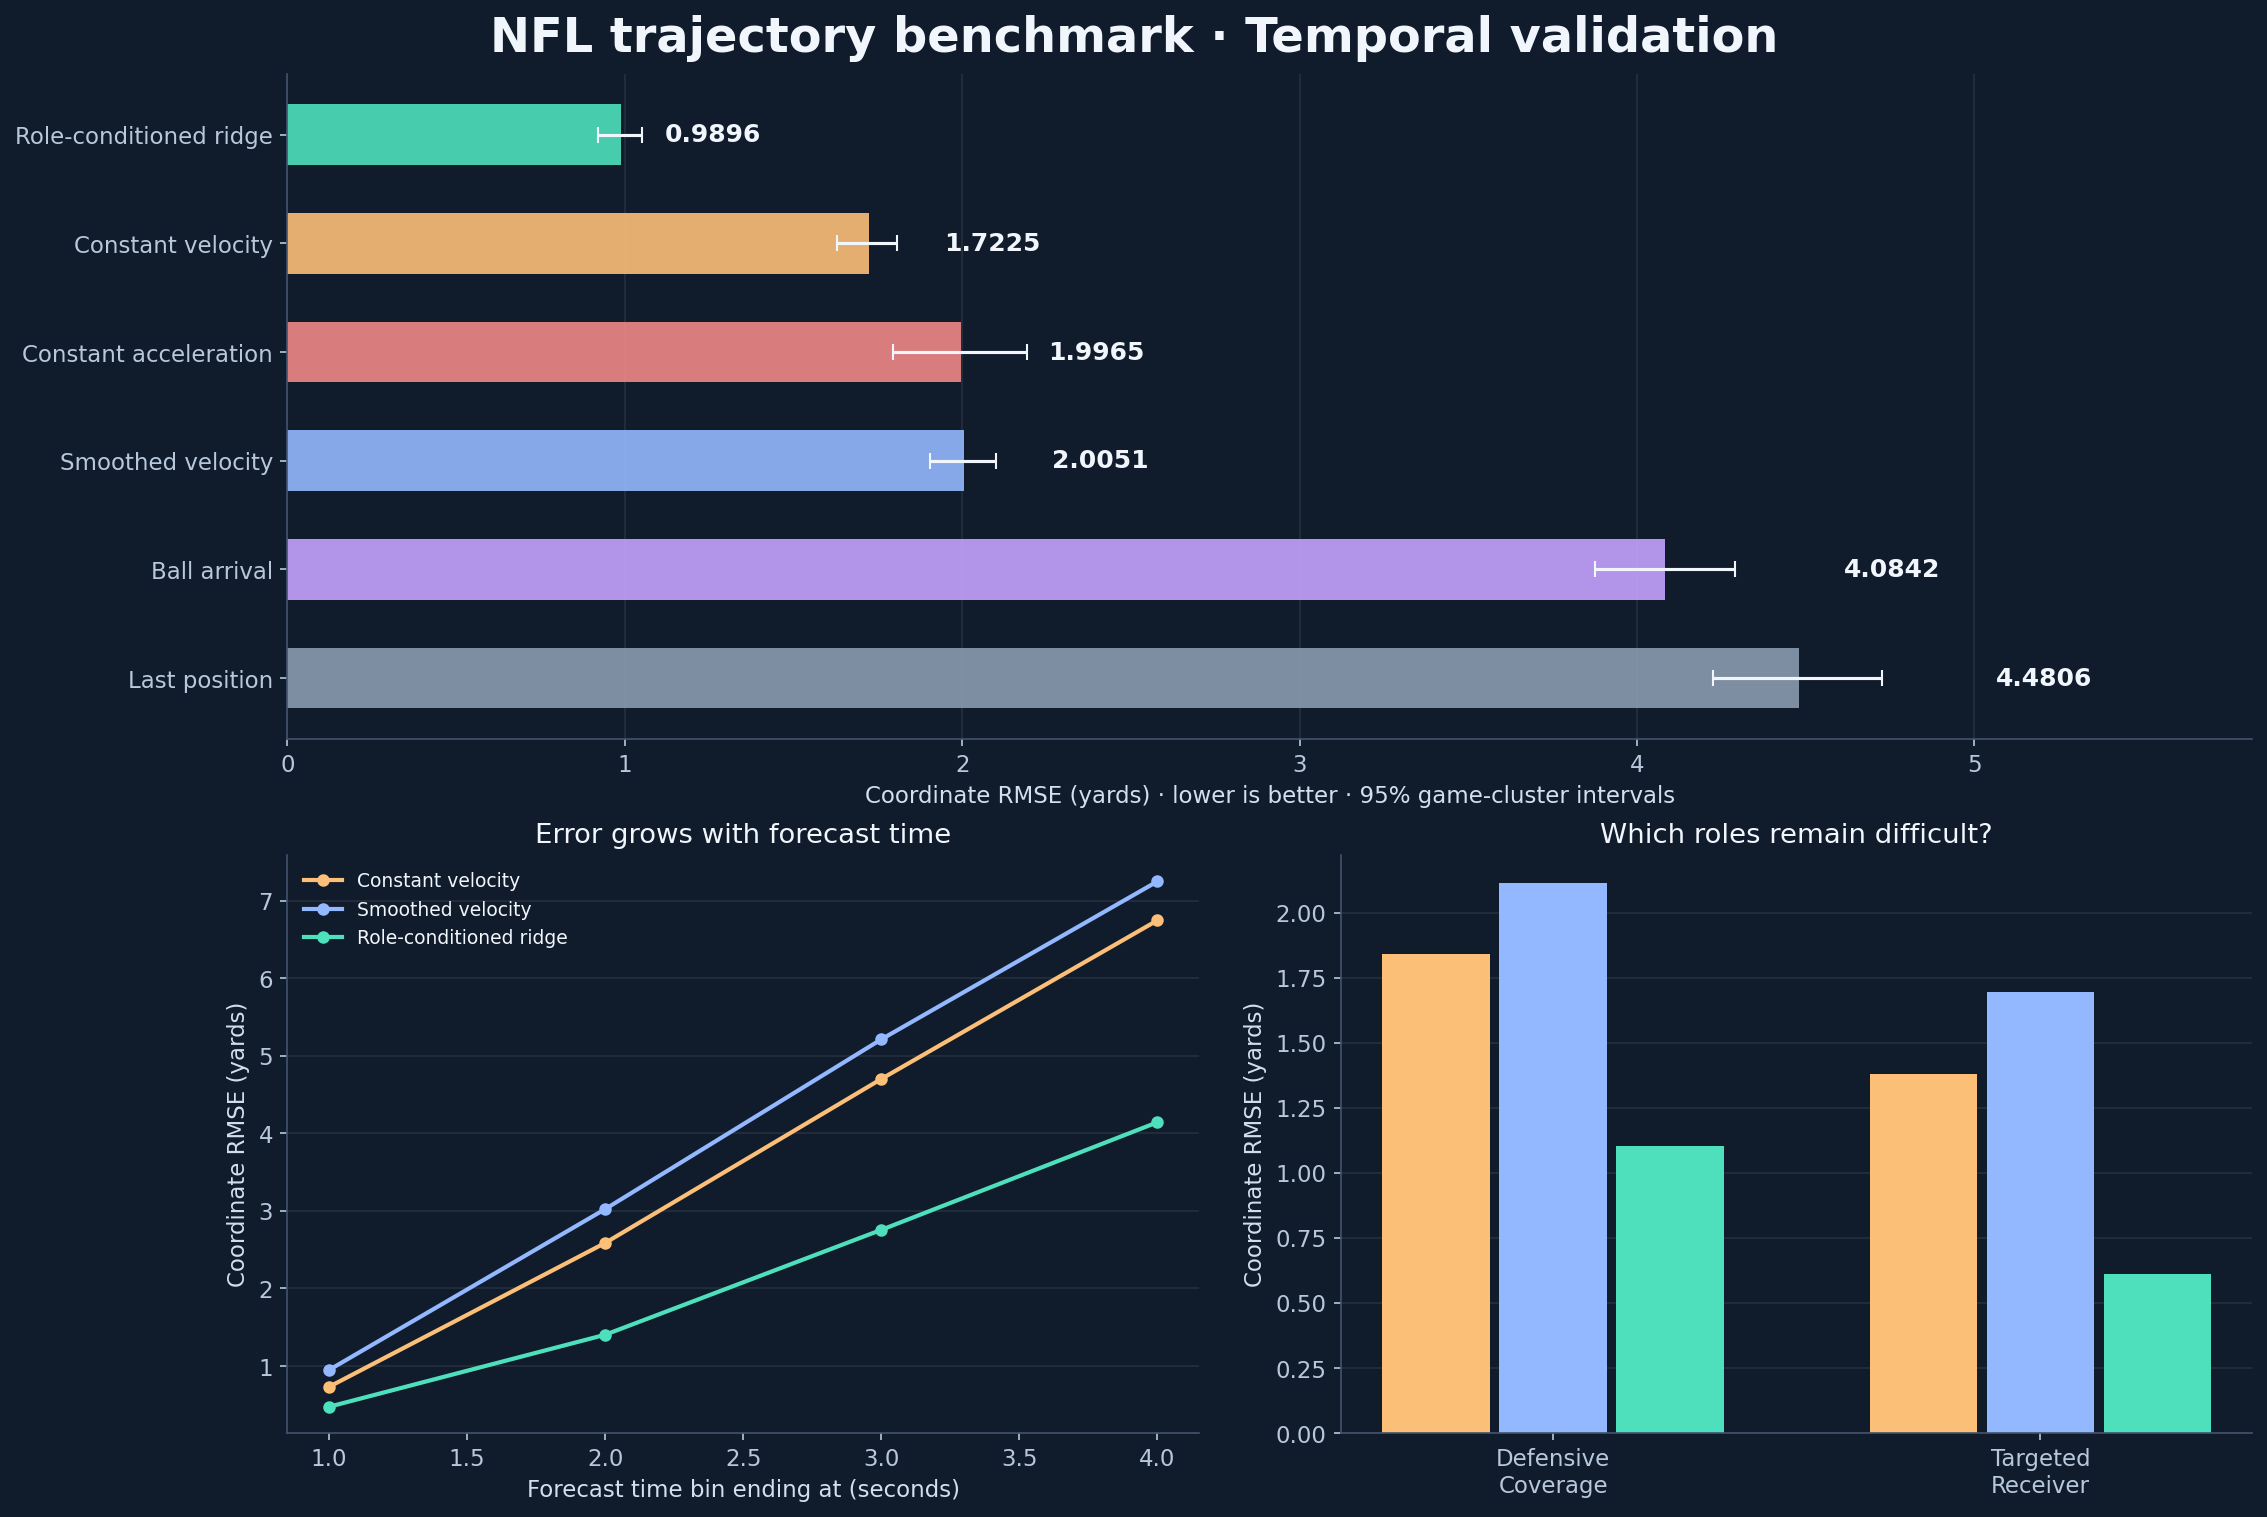

In [3]:
if READY:
    display(Image(filename=str(RESULTS / "benchmark.png")))

## Interpret the learned weights

The six basis vectors are last velocity × time, recent velocity × time,
acceleration × time²/2, and the vector to the landing point multiplied by normalized
time, normalized time², and normalized time³. Training-RMS scaling and ridge stabilize
the fit. Coordinates share coefficients, preserving rotation and translation equivariance.
An unseen role uses the global training fit. Correlated weights should be interpreted jointly.

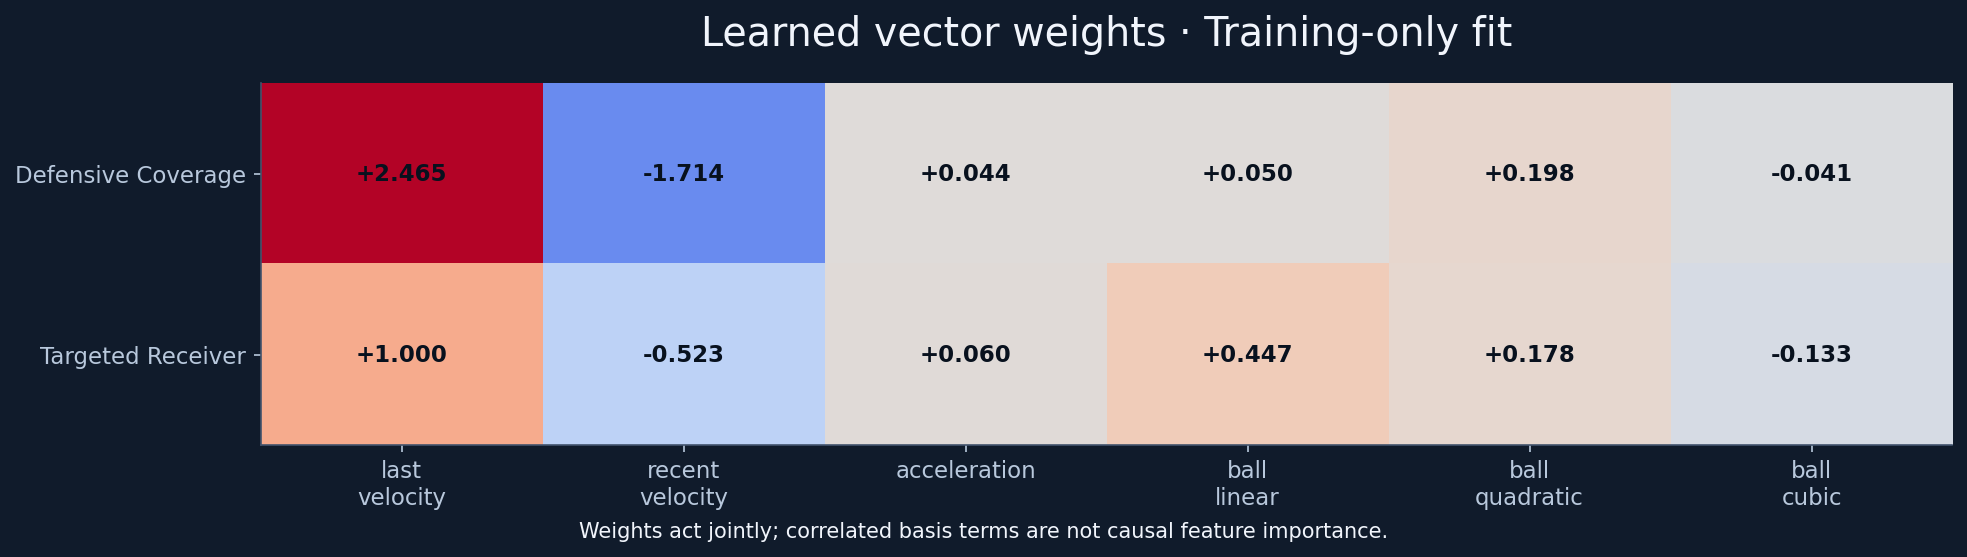

,model,plays,median_ms,p95_ms,includes,excludes,machine,python,platform
0,role_ridge,32,27.086322,87.751932,feature construction and prediction; one compl...,"CSV loading, networking, server startup",x86_64,3.11.15,Linux-6.18.35-x86_64-with-glibc2.39


In [4]:
if READY:
    display(Image(filename=str(RESULTS / "coefficients.png")))
    latency = json.loads((RESULTS / "latency.json").read_text())
    display(pd.DataFrame([latency]))

## Watch trajectories and reproduce the experiment

Open `artifacts/benchmark/report.html` for the full offline report and animated field.
The example is the first validation play by game/play ID, selected independently of its errors.

```bash
nfl benchmark
nfl backup
```

A repeat verifies cached files and reuses completed weekly stages. Changed inputs, model
source, or dependencies invalidate the corresponding checkpoints. Interrupted stages are
recomputed, and a corrupt artifact never counts as a completed result.

## What this result establishes

Game-cluster bootstrap intervals resample entire games 2,000 times, preserving player and
frame dependence within each sampled game. Paired intervals compare against constant velocity.
They describe this validation sample, not performance on every future season. Repeated model
selection can overfit validation. Keep the holdout reserved until model selection is locked.
Next: richer interaction features, residual models, then checkpointed temporal neural models.